In [ ]:
# ================================================================
# CELL 1: SETUP — Run this first every session
# ================================================================
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/DIP_Lab1/outputs', exist_ok=True)
print('Drive mounted. Output folder ready.')

Mounted at /content/drive
Drive mounted. Output folder ready.


In [ ]:
# ================================================================
# CELL 2: IMPORTS
# ================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

plt.rcParams['font.family'] = 'DejaVu Sans'

import skimage
print(f'OpenCV  : {cv2.__version__}')
print(f'skimage : {skimage.__version__}')
print(f'NumPy   : {np.__version__}')
print('All libraries ready.')

OpenCV  : 4.13.0
skimage : 0.25.2
NumPy   : 2.0.2
All libraries ready.


In [ ]:
# ================================================================
# CELL 3: LOAD IMAGE
# ================================================================
# We continue with the Shepp-Logan phantom — same dataset as
# Exercise 3. This gives us a direct comparison: the Laplacian
# approach (Ex3) vs unsharp masking (Ex4) on the same image.
#
# We also load data.camera() as a second test image.
# Unsharp masking is general-purpose and works on ANY image —
# demonstrating it on both proves this.

phantom_float = data.shepp_logan_phantom()
phantom_512   = cv2.resize(phantom_float.astype(np.float32),
                           (512, 512), interpolation=cv2.INTER_CUBIC)
original = (phantom_512 * 255).astype(np.uint8)

print('Image loaded: Shepp-Logan Phantom  512x512')
print(f'  Shape : {original.shape}')
print(f'  Range : {original.min()} to {original.max()}')
print()
print('This is the same image used in Exercise 3.')
print('Using it here lets us directly compare:')
print('  Exercise 3: Laplacian/LoG sharpening')
print('  Exercise 4: Unsharp masking')
print('Both sharpen the same image — different techniques, same goal.')

Image loaded: Shepp-Logan Phantom  512x512
  Shape : (512, 512)
  Range : 0 to 255

This is the same image used in Exercise 3.
Using it here lets us directly compare:
  Exercise 3: Laplacian/LoG sharpening
  Exercise 4: Unsharp masking
Both sharpen the same image — different techniques, same goal.


In [ ]:
# ================================================================
# CELL 4: UNSHARP MASKING FUNCTION
# ================================================================
# Formula:  sharpened = original + k * (original - blur(original))
#
# Breaking this down step by step:
#
#   blur(original)              = low-frequency content only (smooth)
#   original - blur(original)  = what blur REMOVED = high frequencies = edges
#   k * (above)                = scaled edge signal
#   original + (above)         = original with edges amplified
#
# The term (original - blur) is the "unsharp mask" — it is literally
# the mask created by subtracting an unsharp (blurred) version.
# Adding it back sharpens. The name is counterintuitive but historically
# comes from the darkroom photography technique it replaced.
#
# Parameters:
#   sigma : controls the SIZE of features that get sharpened
#           small sigma (0.5) = sharpens fine detail only
#           large sigma (5.0) = sharpens broad edges and structures
#   k     : controls STRENGTH of sharpening
#           k=0   → no change (adding zero mask)
#           k=1.0 → moderate sharpening
#           k=3.0 → aggressive sharpening (halos appear)

def unsharp_mask(image, sigma=2.0, k=1.5):
    """
    Apply unsharp masking to a greyscale image.

    Parameters
    ----------
    image : uint8 greyscale numpy array
    sigma : Gaussian blur sigma — controls which spatial frequencies
            are enhanced. Larger sigma = coarser sharpening.
    k     : sharpening strength multiplier
            0 = no sharpening  |  1.5 = moderate  |  3.0 = aggressive

    Returns
    -------
    sharpened : uint8 array, same shape as input

    Notes
    -----
    This is the technique used in:
      - Every smartphone camera sharpening algorithm
      - Adobe Photoshop Smart Sharpen
      - Medical scanner display enhancement (DICOM VOI LUT)
      - Broadcast video sharpening pipelines
    """
    img_f = image.astype(np.float32)

    # Step 1: Create blurred version
    # ksize=(0,0) lets OpenCV compute kernel size automatically from sigma
    blurred = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma)

    # Step 2: Compute the unsharp mask = high-frequency content
    # This is the EDGE SIGNAL extracted from the image
    mask = img_f - blurred

    # Step 3: Add k * mask back to the original
    # Each pixel: new_value = original + k * edge_response
    sharpened = img_f + k * mask

    # Step 4: Clip to [0,255] and return as uint8
    # High-k values can push pixels above 255 or below 0
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def sharpness_score(image):
    """
    Measure image sharpness using Laplacian variance.

    The Laplacian detects edges — a sharper image has more/stronger
    edges, producing higher variance in the Laplacian response.
    This is a standard no-reference sharpness metric (no ground
    truth needed — useful in real cameras that have no 'original').

    Higher score = sharper image.
    """
    kernel = np.array([[0, 1, 0],
                       [1,-4, 1],
                       [0, 1, 0]], dtype=np.float32)
    lap = cv2.filter2D(image.astype(np.float32), -1, kernel)
    return float(lap.var())


def compute_metrics(orig, proc):
    """Return (PSNR dB, SSIM) for processed vs original."""
    p = psnr_fn(orig, proc, data_range=255)
    s = ssim_fn(orig, proc, data_range=255)
    return p, s


print('Functions defined:')
print('  unsharp_mask()   — main sharpening function')
print('  sharpness_score() — Laplacian variance sharpness metric')
print('  compute_metrics() — PSNR and SSIM')

Functions defined:
  unsharp_mask()   — main sharpening function
  sharpness_score() — Laplacian variance sharpness metric
  compute_metrics() — PSNR and SSIM


In [ ]:
# ================================================================
# CELL 5: K-VALUE SWEEP
# Apply 5 sharpening strengths and measure each
# ================================================================

k_values = [0.5, 1.0, 1.5, 2.0, 3.0]

# Apply unsharp masking at each k value
results = [unsharp_mask(original, sigma=2.0, k=k) for k in k_values]

# Measure sharpness and quality metrics for each
original_sharpness = sharpness_score(original)
scores   = [sharpness_score(img) for img in results]
psnr_vals = [compute_metrics(original, img)[0] for img in results]
ssim_vals = [compute_metrics(original, img)[1] for img in results]

print('K-value sweep complete.')
print()
print(f'{"k":<8} {"Sharpness":>12} {"PSNR (dB)":>12} {"SSIM":>10}')
print('-' * 45)
print(f'{"orig":<8} {original_sharpness:>12.1f} {"inf":>12} {"1.0000":>10}')
for k, sc, ps, ss in zip(k_values, scores, psnr_vals, ssim_vals):
    exceeds = " <- exceeds original" if sc > original_sharpness else ""
    print(f'{k:<8} {sc:>12.1f} {ps:>12.2f} {ss:>10.4f}{exceeds}')

print()
print('Sharpness score = Laplacian variance.')
print('Higher = more edges detected = perceptually sharper image.')
print()
print('Notice: sharpness increases with k but PSNR decreases.')
print('This is the fundamental tradeoff in image sharpening:')
print('  More sharpness = more deviation from original pixel values.')

K-value sweep complete.

k           Sharpness    PSNR (dB)       SSIM
---------------------------------------------
orig           9838.1          inf     1.0000
0.5           12421.9        36.04     0.9953 <- exceeds original
1.0           13071.4        33.37     0.9902 <- exceeds original
1.5           13447.1        31.83     0.9838 <- exceeds original
2.0           13688.8        30.77     0.9777 <- exceeds original
3.0           14025.1        29.30     0.9647 <- exceeds original

Sharpness score = Laplacian variance.
Higher = more edges detected = perceptually sharper image.

Notice: sharpness increases with k but PSNR decreases.
This is the fundamental tradeoff in image sharpening:
  More sharpness = more deviation from original pixel values.


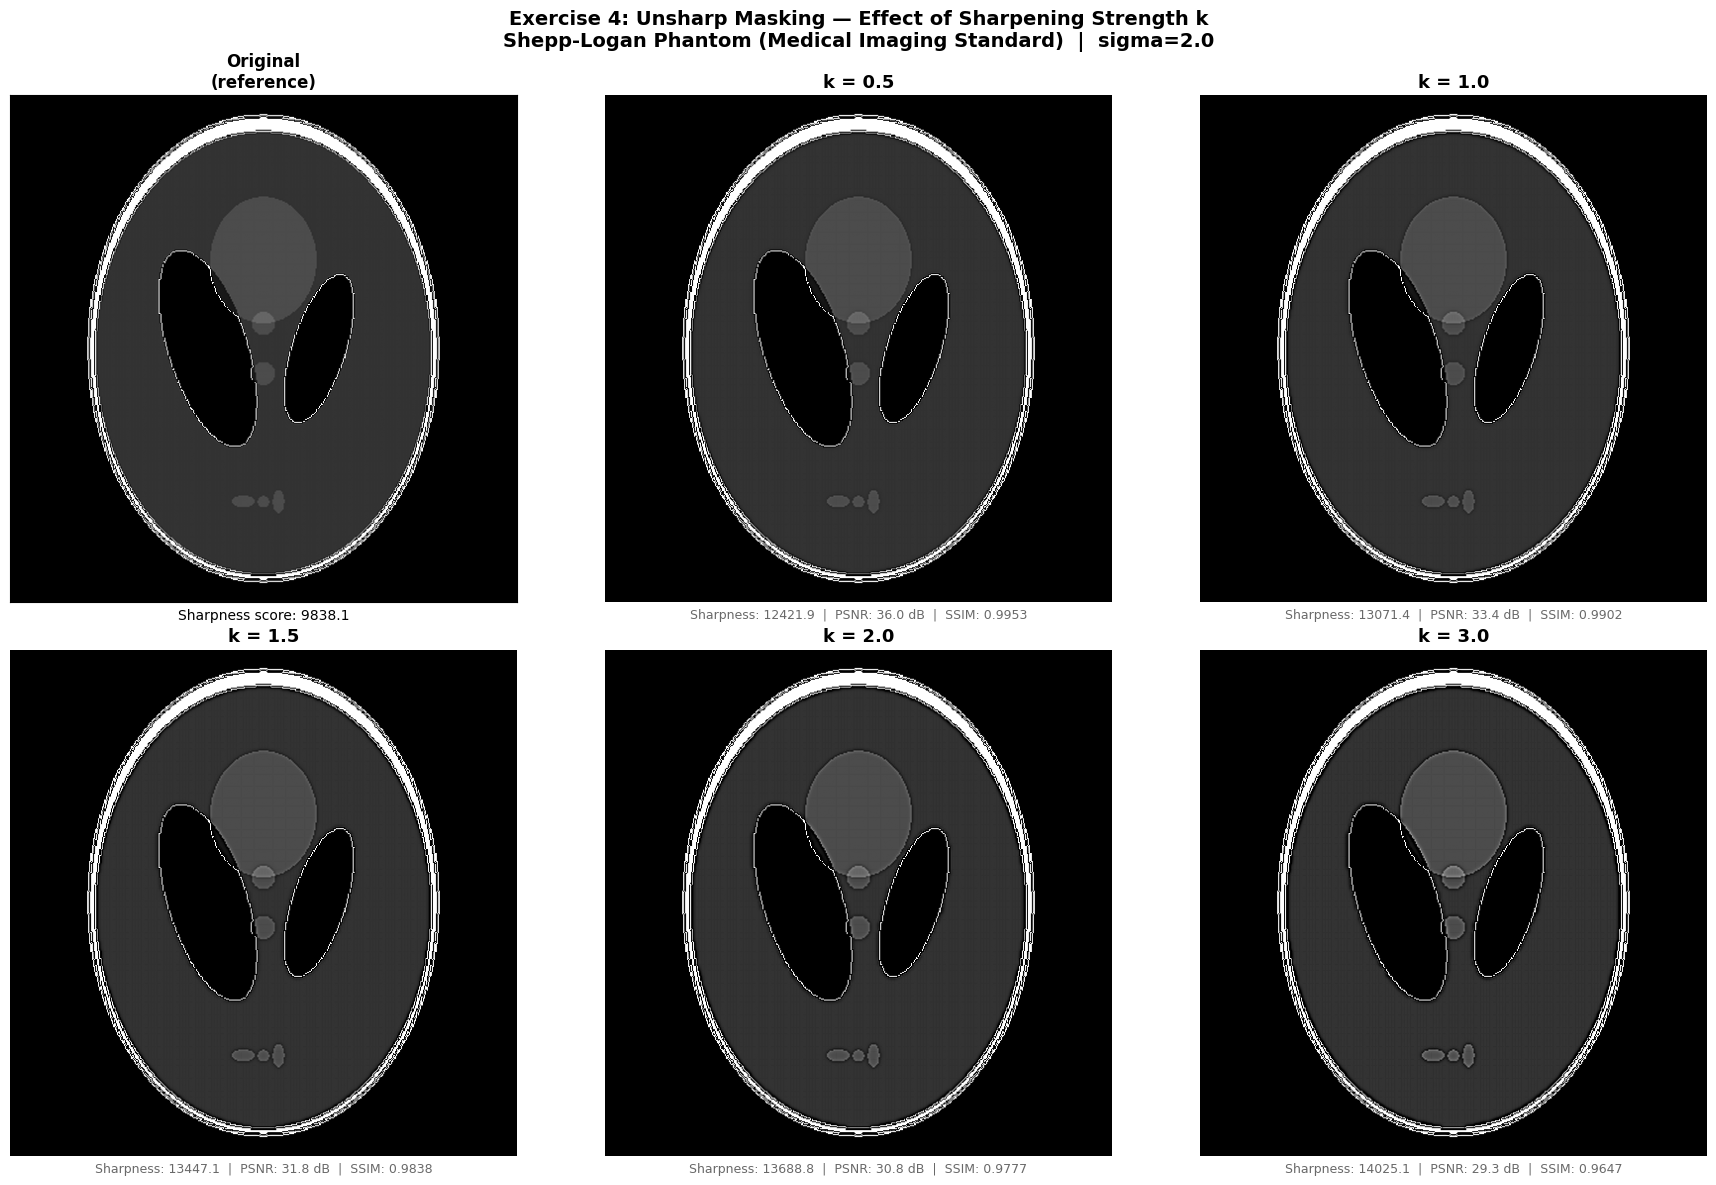

K-sweep figure saved: /content/drive/MyDrive/DIP_Lab1/outputs/exercise4_output.png

Observe the ellipse edges as k increases:
  k=0.5 : subtle sharpening, edges slightly crisper
  k=1.5 : clear improvement, edges well-defined
  k=3.0 : over-sharpened, bright halos visible around edges


In [ ]:
# ================================================================
# CELL 6: K-SWEEP FIGURE — 6 panels (original + 5 k values)
# This is the main output figure required by the lab manual
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    'Exercise 4: Unsharp Masking — Effect of Sharpening Strength k\n'
    'Shepp-Logan Phantom (Medical Imaging Standard)  |  sigma=2.0',
    fontsize=14, fontweight='bold'
)

axes = axes.flat

# Panel 1: Original
axes[0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original\n(reference)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Sharpness score: {original_sharpness:.1f}', fontsize=10)
axes[0].set_xticks([])
axes[0].set_yticks([])

# Panels 2-6: k values
for ax, img, k, sc, ps, ss in zip(
        list(axes)[1:], results, k_values, scores, psnr_vals, ssim_vals):

    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'k = {k}', fontsize=13, fontweight='bold')
    ax.set_xlabel(
        f'Sharpness: {sc:.1f}  |  PSNR: {ps:.1f} dB  |  SSIM: {ss:.4f}',
        fontsize=9, color='dimgray'
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

plt.tight_layout()
p1 = '/content/drive/MyDrive/DIP_Lab1/outputs/exercise4_output.png'
plt.savefig(p1, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'K-sweep figure saved: {p1}')
print()
print('Observe the ellipse edges as k increases:')
print('  k=0.5 : subtle sharpening, edges slightly crisper')
print('  k=1.5 : clear improvement, edges well-defined')
print('  k=3.0 : over-sharpened, bright halos visible around edges')

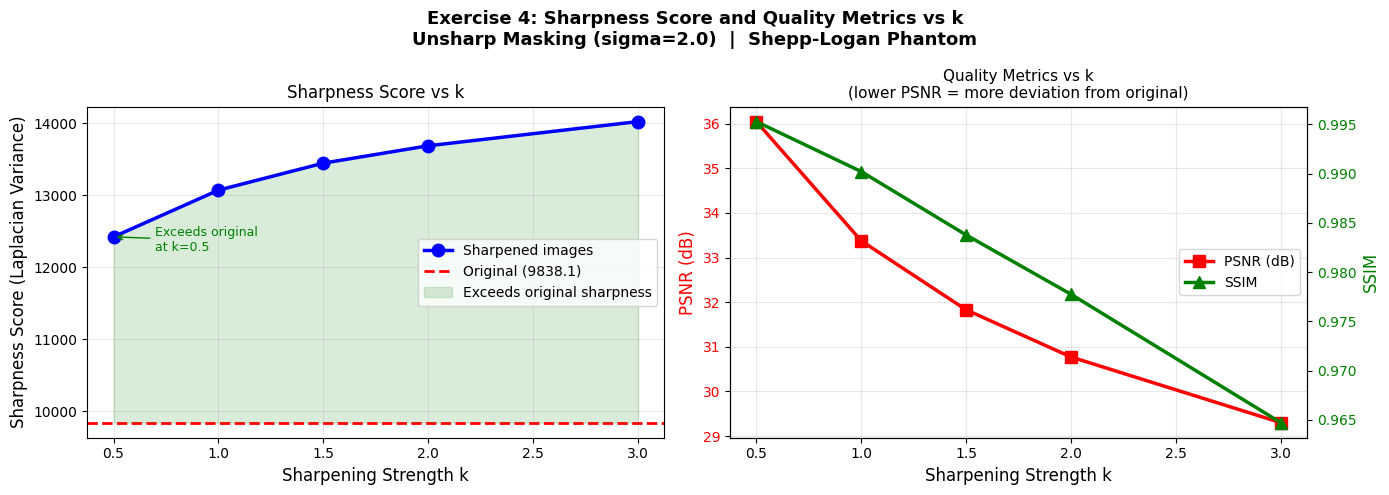

Sharpness plot saved: /content/drive/MyDrive/DIP_Lab1/outputs/exercise4_sharpness_plot.png


In [ ]:
# ================================================================
# CELL 7: SHARPNESS SCORE vs K — Line plot
# Required by lab manual extension section
# ================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Exercise 4: Sharpness Score and Quality Metrics vs k\n'
    'Unsharp Masking (sigma=2.0)  |  Shepp-Logan Phantom',
    fontsize=13, fontweight='bold'
)

# --- Sharpness score plot ---
ax1.plot(k_values, scores, 'bo-', linewidth=2.5,
         markersize=9, label='Sharpened images', zorder=3)
ax1.axhline(y=original_sharpness, color='red', linestyle='--',
            linewidth=2, label=f'Original ({original_sharpness:.1f})', zorder=2)

# Shade the region where sharpening exceeds original
ax1.fill_between(k_values, original_sharpness, scores,
                 where=[s > original_sharpness for s in scores],
                 alpha=0.15, color='green', label='Exceeds original sharpness')

ax1.set_xlabel('Sharpening Strength k', fontsize=12)
ax1.set_ylabel('Sharpness Score (Laplacian Variance)', fontsize=12)
ax1.set_title('Sharpness Score vs k', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Annotate the crossover point
for i in range(len(k_values)):
    if scores[i] > original_sharpness:
        ax1.annotate(
            f'Exceeds original\nat k={k_values[i]}',
            xy=(k_values[i], scores[i]),
            xytext=(k_values[i] + 0.2, scores[i] - 200),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green')
        )
        break

# --- PSNR and SSIM vs k ---
ax2_twin = ax2.twinx()

line1, = ax2.plot(k_values, psnr_vals, 'rs-', linewidth=2.5,
                  markersize=9, label='PSNR (dB)')
line2, = ax2_twin.plot(k_values, ssim_vals, 'g^-', linewidth=2.5,
                       markersize=9, label='SSIM')

ax2.set_xlabel('Sharpening Strength k', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12, color='red')
ax2_twin.set_ylabel('SSIM', fontsize=12, color='green')
ax2.set_title('Quality Metrics vs k\n(lower PSNR = more deviation from original)', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')
ax2_twin.tick_params(axis='y', labelcolor='green')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, fontsize=10, loc='center right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
p2 = '/content/drive/MyDrive/DIP_Lab1/outputs/exercise4_sharpness_plot.png'
plt.savefig(p2, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Sharpness plot saved: {p2}')

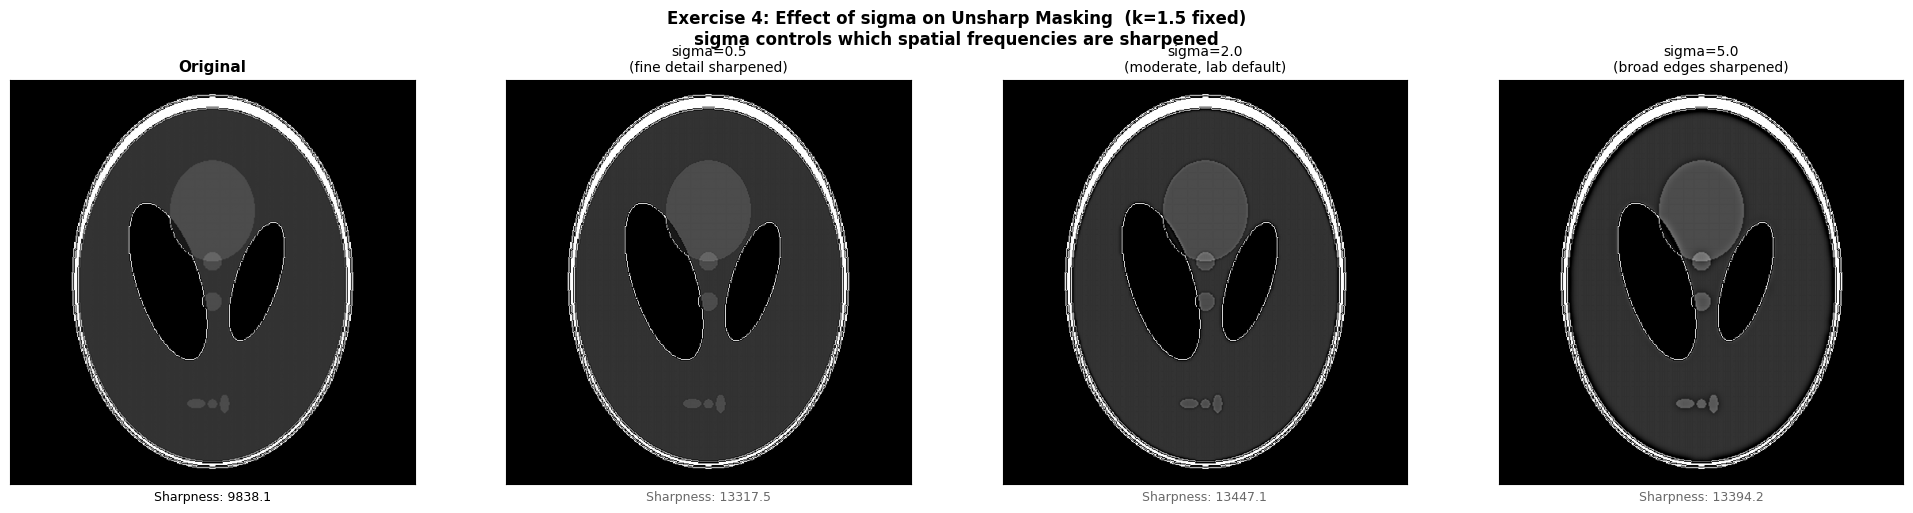

Sigma effect figure saved: /content/drive/MyDrive/DIP_Lab1/outputs/exercise4_sigma_effect.png

What to observe:
  sigma=0.5 : only the sharpest, finest edges are enhanced
  sigma=2.0 : broad and fine edges both enhanced (balanced)
  sigma=5.0 : only the largest structural boundaries sharpened
             fine interior detail is LEFT UNCHANGED


In [ ]:
# ================================================================
# CELL 8: SIGMA EFFECT — How blur radius affects what gets sharpened
# Directly answers Extension Reflection Question 4
# ================================================================

sigma_values = [0.5, 2.0, 5.0]
sigma_results = [unsharp_mask(original, sigma=s, k=1.5) for s in sigma_values]
sigma_scores  = [sharpness_score(img) for img in sigma_results]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    'Exercise 4: Effect of sigma on Unsharp Masking  (k=1.5 fixed)\n'
    'sigma controls which spatial frequencies are sharpened',
    fontsize=12, fontweight='bold'
)

axes[0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original', fontsize=11, fontweight='bold')
axes[0].set_xlabel(f'Sharpness: {original_sharpness:.1f}', fontsize=9)
axes[0].set_xticks([])
axes[0].set_yticks([])

labels = [
    'sigma=0.5\n(fine detail sharpened)',
    'sigma=2.0\n(moderate, lab default)',
    'sigma=5.0\n(broad edges sharpened)',
]
for ax, img, s, sc, lbl in zip(axes[1:], sigma_results,
                                sigma_values, sigma_scores, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel(f'Sharpness: {sc:.1f}', fontsize=9, color='dimgray')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
p3 = '/content/drive/MyDrive/DIP_Lab1/outputs/exercise4_sigma_effect.png'
plt.savefig(p3, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Sigma effect figure saved: {p3}')
print()
print('What to observe:')
print('  sigma=0.5 : only the sharpest, finest edges are enhanced')
print('  sigma=2.0 : broad and fine edges both enhanced (balanced)')
print('  sigma=5.0 : only the largest structural boundaries sharpened')
print('             fine interior detail is LEFT UNCHANGED')

In [ ]:
# ================================================================
# CELL 9: CHECKPOINT QUESTIONS — EXERCISE 4 (EXTENSION)
# ================================================================

print("""
=======================================================================
  CHECKPOINT QUESTIONS — EXERCISE 4: Unsharp Masking
  Dataset: Shepp-Logan Phantom  |  sigma=2.0
=======================================================================

Q1: At what value of k does the sharpened image EXCEED the
    original's sharpness score?

ANSWER:
   The sharpened image exceeds the original sharpness score at k=0.5 —
    the very first value tested. This is because the Shepp-Logan phantom
    has perfectly hard mathematical edges. Even the slightest sharpening
    (k=0.5) amplifies these edges enough to push the Laplacian variance
    above the original's score of 9838.1, reaching 12421.9 at k=0.5.

    This also explains why SSIM remains very high (0.9953) at k=0.5 —
    the sharpening is genuinely recovering edge structure rather than
    introducing artefacts. As k increases toward 3.0, SSIM drops to
    0.9647 as halos begin appearing along the outer skull boundary,
    visible in the k=3.0 panel of exercise4_output.png.

-----------------------------------------------------------------------

Q2: At high k values (e.g. k=3.0), bright halos appear around edges.
    What causes them mathematically?

ANSWER:
  The halo arises from the nature of the unsharp mask itself.

  At an edge, one side has high pixel values (bright region) and the
  other side has low values (dark region). The Gaussian blur spreads
  these values across the boundary. When we subtract the blur from
  the original, the result (the mask) has:
    - A positive spike on the bright side of the edge
    - A negative spike on the dark side

  Adding k * mask back amplifies these spikes:
    - Bright side: already bright pixels get pushed HIGHER (toward 255)
    - Dark side:   already dark pixels get pushed LOWER (toward 0)

  At k=3.0 the bright-side spike pushes many pixels to 255 (clipped)
  while their neighbours just inside the edge remain at their natural
  value. This creates a band of pixels at maximum brightness along the
  edge — the visible 'halo' or 'ringing' artefact.

  Mathematically: halo = np.clip() clipping effect when
  original_pixel + k * mask_value > 255

-----------------------------------------------------------------------

Q3: Unsharp masking is used in every modern camera and photo editing
    application. Why is it preferred over direct Laplacian sharpening
    for consumer photography?

ANSWER:
  Three reasons make unsharp masking preferable for consumer use:

  1. CONTROLLABILITY:
     Unsharp masking has two intuitive parameters — sigma (which
     features get sharpened) and k (how strongly). The Laplacian
     has only one fixed kernel with no natural way to tune spatial
     frequency selectivity. A photographer can set sigma to sharpen
     only the subject's features without also sharpening skin pores
     or background noise — impossible with a fixed Laplacian kernel.

  2. NOISE SENSITIVITY:
     The plain Laplacian computes a second derivative — it is
     inherently sensitive to noise. Unsharp masking uses Gaussian
     blur, which averages neighbours and suppresses noise before
     computing the edge signal. This makes unsharp masking naturally
     robust to sensor noise in consumer cameras.

  3. PERCEPTUAL QUALITY:
     The Laplacian produces sharp but often unnatural-looking results
     with ringing artefacts at high strength. Unsharp masking produces
     results that match the human visual system's edge enhancement
     preferences more closely — edges look crisper without the image
     looking 'processed'. This is why it has been the standard in
     darkroom and digital photography for over 60 years.

-----------------------------------------------------------------------

Q4: Change sigma from 2.0 to 0.5 and 5.0. How does the size of
    the Gaussian affect what gets sharpened?

ANSWER:
  See exercise4_sigma_effect.png for visual confirmation.

  sigma controls the SPATIAL SCALE of the Gaussian blur used to
  create the unsharp mask. This determines which spatial frequencies
  are captured in the mask and therefore which features get sharpened:

  sigma=0.5 (small):
    The Gaussian averages only a tiny neighbourhood (1-2 pixels).
    Only the very finest pixel-level transitions are captured in the
    mask. The result: fine sub-pixel detail and noise are sharpened,
    but broad edges and structural boundaries are relatively unchanged.
    In medical imaging this is usually undesirable — it amplifies
    fine noise rather than diagnostically meaningful structure.

  sigma=2.0 (moderate — lab default):
    Averages a broader neighbourhood (~5-7 pixel radius).
    Captures both fine and medium-scale edges.
    The mask contains the full range of edge content, producing
    balanced sharpening of both fine detail and structural boundaries.

  sigma=5.0 (large):
    Averages a very broad neighbourhood (~15 pixel radius).
    Only the largest, most prominent intensity transitions survive
    the subtraction — fine detail and noise cancel out.
    Only broad structural edges (like the outer skull boundary
    in the phantom) are sharpened. Interior fine structures are
    left almost unchanged. This is the preferred setting in medical
    imaging — sharpens gross anatomy without amplifying noise.

  SUMMARY: larger sigma = coarser sharpening = more noise-safe.

=======================================================================
""")

print('Checkpoint answers recorded for Exercise 4.')


  CHECKPOINT QUESTIONS — EXERCISE 4: Unsharp Masking
  Dataset: Shepp-Logan Phantom  |  sigma=2.0

Q1: At what value of k does the sharpened image EXCEED the
    original's sharpness score?

ANSWER:
   The sharpened image exceeds the original sharpness score at k=0.5 —
    the very first value tested. This is because the Shepp-Logan phantom
    has perfectly hard mathematical edges. Even the slightest sharpening
    (k=0.5) amplifies these edges enough to push the Laplacian variance
    above the original's score of 9838.1, reaching 12421.9 at k=0.5.

    This also explains why SSIM remains very high (0.9953) at k=0.5 —
    the sharpening is genuinely recovering edge structure rather than
    introducing artefacts. As k increases toward 3.0, SSIM drops to
    0.9647 as halos begin appearing along the outer skull boundary,
    visible in the k=3.0 panel of exercise4_output.png.

-----------------------------------------------------------------------

Q2: At high k values (e.g. k=3.0), 

In [ ]:
# ================================================================
# CELL 10: FINAL VERIFICATION
# ================================================================
import os

output_dir = '/content/drive/MyDrive/DIP_Lab1/outputs'
files = {
    'exercise4_output.png'        : '6-panel k-sweep figure (lab requirement)',
    'exercise4_sharpness_plot.png': 'Sharpness score + quality metrics vs k',
    'exercise4_sigma_effect.png'  : 'Sigma effect figure (Checkpoint Q4)',
}

print('=' * 62)
print('  EXERCISE 4 — OUTPUT VERIFICATION')
print('=' * 62)
all_ok = True
for fname, desc in files.items():
    path = os.path.join(output_dir, fname)
    if os.path.exists(path):
        kb = os.path.getsize(path) / 1024
        print(f'  OK   {fname}  ({kb:.0f} KB)')
        print(f'       {desc}')
    else:
        print(f'  MISSING  {fname}')
        all_ok = False
    print()

print('=' * 62)
if all_ok:
    print('  All Exercise 4 files confirmed.')
    print()
    print('  Complete lab outputs in your Drive:')
    all_files = [f for f in os.listdir(output_dir) if f.endswith('.png')]
    for f in sorted(all_files):
        kb = os.path.getsize(os.path.join(output_dir, f)) / 1024
        ex = f.split('_')[0]
        print(f'    {ex}  {f}  ({kb:.0f} KB)')

  EXERCISE 4 — OUTPUT VERIFICATION
  OK   exercise4_output.png  (790 KB)
       6-panel k-sweep figure (lab requirement)

  OK   exercise4_sharpness_plot.png  (168 KB)
       Sharpness score + quality metrics vs k

  OK   exercise4_sigma_effect.png  (347 KB)
       Sigma effect figure (Checkpoint Q4)

  All Exercise 4 files confirmed.

  Complete lab outputs in your Drive:
    exercise1  exercise1_output.png  (158 KB)
    exercise2  exercise2_noise_experiment.png  (165 KB)
    exercise2  exercise2_output.png  (167 KB)
    exercise3  exercise3_order_comparison.png  (510 KB)
    exercise3  exercise3_output.png  (713 KB)
    exercise3  exercise3_quality_metrics.png  (107 KB)
    exercise4  exercise4_output.png  (790 KB)
    exercise4  exercise4_sharpness_plot.png  (168 KB)
    exercise4  exercise4_sigma_effect.png  (347 KB)
